# 5. Ask the same question with SQL and pandas
## Goal
Query an in-memory database, verify SQL/pandas agreement, and choose suitable charts.
Course Module 7. All input records are invented and created below; no dependency on previous notebooks.
## Setup
Uses sqlite3 from Python, pandas, and Matplotlib.
References: [SQLite API](https://docs.python.org/3/library/sqlite3.html), [Matplotlib](https://matplotlib.org/stable/users/explain/quick_start.html).
## Steps
### 1. Define one order per row

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.DataFrame({"order_id": range(1, 7), "date": ["2026-01-01", "2026-01-01", "2026-01-02", "2026-01-02", "2026-01-03", "2026-01-03"], "customer": ["A", "B", "A", "C", "B", "A"], "amount": [12., 8., 15., 10., 20., 5.]})
print(orders.to_string(index=False))
assert orders["order_id"].is_unique

 order_id       date customer  amount
        1 2026-01-01        A    12.0
        2 2026-01-01        B     8.0
        3 2026-01-02        A    15.0
        4 2026-01-02        C    10.0
        5 2026-01-03        B    20.0
        6 2026-01-03        A     5.0


### 2. Query and reconcile
Use a bound parameter for a value. `:memory:` creates a temporary database; the connection is closed explicitly.

In [2]:
connection = sqlite3.connect(":memory:")
try:
    orders.to_sql("orders", connection, index=False, if_exists="replace")
    query = """
    SELECT customer, SUM(amount) AS total
    FROM orders
    WHERE amount >= ?
    GROUP BY customer
    ORDER BY customer
    """
    sql_summary = pd.read_sql_query(query, connection, params=(0,))
finally:
    connection.close()
pandas_summary = orders.loc[orders["amount"] >= 0].groupby("customer", as_index=False)["amount"].sum().rename(columns={"amount": "total"})
pd.testing.assert_frame_equal(sql_summary, pandas_summary)
print(sql_summary.to_string(index=False))

customer  total
       A   32.0
       B   28.0
       C   10.0


### 3. Make three charts with distinct questions
Category totals, chronological change, and a distribution show different aspects of the same six observations.

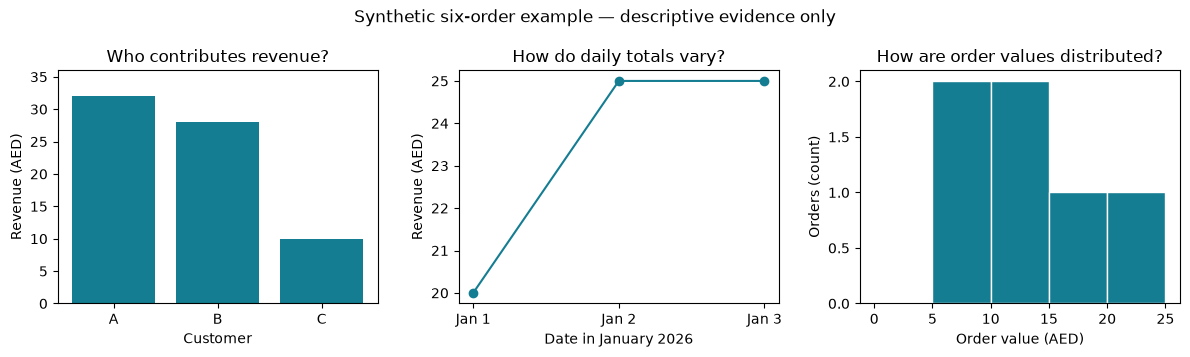

In [3]:
orders["date"] = pd.to_datetime(orders["date"])
daily = orders.groupby("date")["amount"].sum().sort_index()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].bar(sql_summary["customer"], sql_summary["total"], color="#147d92")
axes[0].set(title="Who contributes revenue?", xlabel="Customer", ylabel="Revenue (AED)", ylim=(0, 36))
axes[1].plot(daily.index, daily.values, marker="o", color="#147d92")
axes[1].set(title="How do daily totals vary?", xlabel="Date in January 2026", ylabel="Revenue (AED)")
axes[1].set_xticks(daily.index, ["Jan 1", "Jan 2", "Jan 3"])
axes[2].hist(orders["amount"], bins=[0, 5, 10, 15, 20, 25], color="#147d92", edgecolor="white")
axes[2].set(title="How are order values distributed?", xlabel="Order value (AED)", ylabel="Orders (count)")
fig.suptitle("Synthetic six-order example — descriptive evidence only", fontsize=12)
fig.tight_layout()
plt.show()

## Checks
SQL and pandas should agree. Customer A totals 32 AED, B 28, and C 10. Daily totals are 20, 25, and 25 AED. Six invented orders cannot establish a durable trend or a causal explanation.
## Next Steps
Complete exercises 23–25. Rebuild these chart types using your cleaned retail data and explain one limitation of each. Add a null amount in a copy of the table and compare `COUNT(*)` with `COUNT(amount)`.